Episode 0 | Reward: 1 | Probs: [0.65361745 0.34638255]
Episode 50 | Reward: 1 | Probs: [0.19281321 0.80718679]
Episode 100 | Reward: 1 | Probs: [0.07903591 0.92096409]
Episode 150 | Reward: 1 | Probs: [0.04601791 0.95398209]
Episode 200 | Reward: 1 | Probs: [0.03206056 0.96793944]
Episode 250 | Reward: 1 | Probs: [0.02490272 0.97509728]


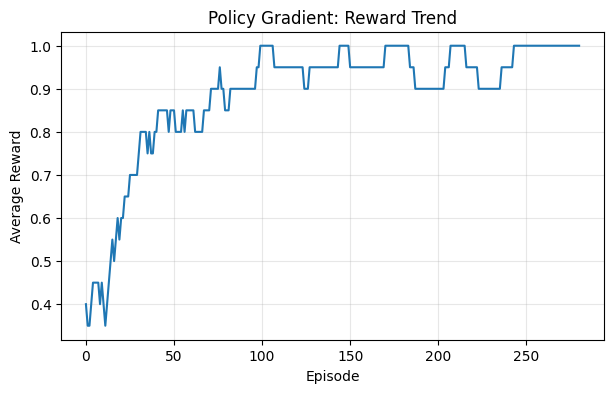

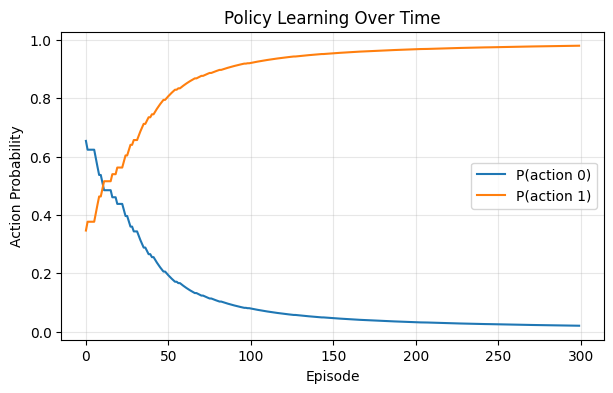

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Policy parameters (logits)
theta = np.random.randn(2)

lr = 0.1
episodes = 300
rewards = []
action_probs = []

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

for ep in range(episodes):
    # Policy
    probs = softmax(theta)
    action_probs.append(probs.copy())

    # Sample action
    action = np.random.choice(2, p=probs)

    # Reward function
    reward = 1 if action == 1 else 0
    rewards.append(reward)

    # Policy Gradient update
    grad = -probs
    grad[action] += 1

    theta += lr * grad * reward

    if ep % 50 == 0:
        print(f"Episode {ep} | Reward: {reward} | Probs: {probs}")

# Visualization
# 1. Reward over time
plt.figure(figsize=(7,4))
plt.plot(np.convolve(rewards, np.ones(20)/20, mode='valid'))
plt.title("Policy Gradient: Reward Trend")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(alpha=0.3)
plt.show()

# 2. Policy Evolution
action_probs = np.array(action_probs)

plt.figure(figsize=(7,4))
plt.plot(action_probs[:,0], label="P(action 0)")
plt.plot(action_probs[:,1], label="P(action 1)")
plt.xlabel("Episode")
plt.ylabel("Action Probability")
plt.title("Policy Learning Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()